## Import libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Download the data

In [ ]:
# parameters
ticker = 'SPY'
start_date = '2016-01-01'
end_date = '2026-01-01'

# download the data
print(f'Fetching data for {ticker}')
print(f'Time period {start_date} to {end_date}')

df = yf.download(ticker, start=start_date, end=end_date)
df.head()

Fetching data for SPY
Time period 2016-01-01 to 2026-01-01


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2016-01-04,169.471527,169.479953,167.422889,169.024707,222353500
2016-01-05,169.758224,170.213470,168.653820,169.791941,110845800
2016-01-06,167.616791,168.662174,166.588259,167.212114,152112600
2016-01-07,163.595474,166.453442,163.207662,164.674588,213436100
2016-01-08,161.799744,165.112969,161.513107,164.556548,209817200


## Calculate log return: (ln(price_today/price_yesterday))

### We need this feature since log return will normalise the data and keep the math nice. Percentage increases are not symmetrical and log return is a good statistic for describing the volatility of the market.

In [22]:
# we only care about 'Close' price for this model
log_returns = df[['Close']]
log_returns.rename(columns={'Close':'Price'}, inplace=True)
log_returns['log_return'] = np.log(log_returns['Price'] / log_returns['Price'].shift(1))

# drop the first row since it doesn't have a log return value
log_returns = log_returns.iloc[1:]

log_returns.head()

Price,Price,log_return
Ticker,SPY,
Date,,
2016-01-07,163.595474,-0.024284
2016-01-08,161.799744,-0.011037
2016-01-11,161.959915,0.000989
2016-01-12,163.266663,0.008036
2016-01-13,159.194687,-0.025257


## Visualise the log returns

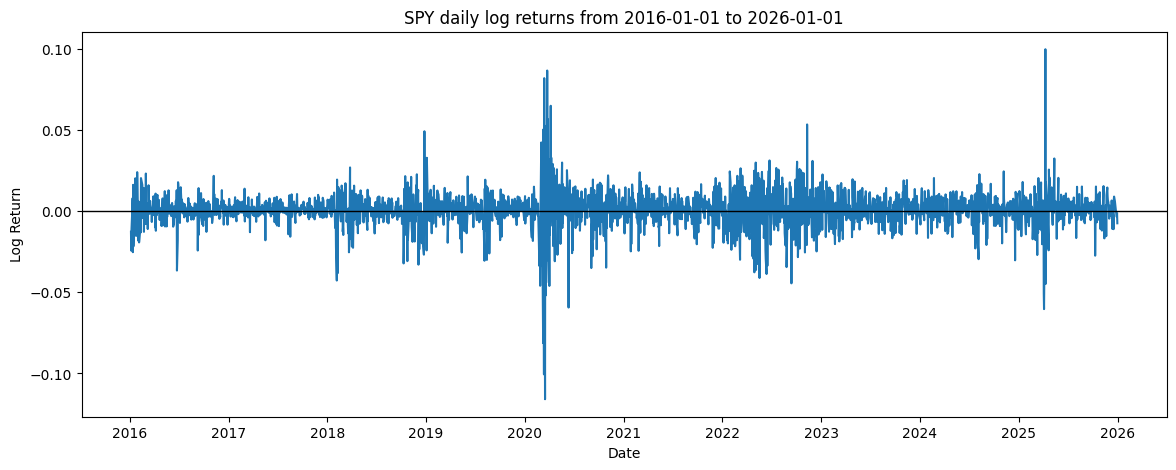

In [20]:
# plot the log returns to spot the high and low volatile regimes
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['log_return'])
plt.title(f'{ticker} daily log returns from {start_date} to {end_date}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linewidth=1) # add a horizontal line at y=0
plt.show()